This notebook demonstrates fitting a linear regression to sample data. 

Given an exact gradient and y-intercept, uniform points along the line are given random slight offsets, serving as sample data with random error. A linear regression is fit to this sample data and compared to the original line used to generate the sample data. 

In [1]:
# importing dependencies
import numpy as np
import matplotlib.pyplot as plt
from numpy import random

In [2]:
# initial conditions
rng = np.random.default_rng(seed=21)

true_m = 5
true_c = 16

n = 50
x_range = 10
sim = 5

true_x = np.linspace(0, x_range, n)
true_y = true_m * true_x + true_c

noise = rng.uniform(-2, 2, size=(sim, n))

x_samples = true_x + rng.uniform(-0.5, 0.5, size=(sim, n))
y_samples = true_y + rng.uniform(-0.5, 0.5, size=(sim, n))

In [3]:
def linear_regression(y, x):
    m = (np.mean(x * y) - np.mean(x) * np.mean(y)) / \
    (np.mean(x**2) - np.mean(x)**2)
    c = np.mean(y) - m * np.mean(x)
    return m, c

In [4]:
# calculating and storing parameters for each sample
m_val = []
c_val = []

for _ in range(sim):
    m, c = linear_regression(y_samples[_], x_samples[_])
    m_val.append(m)
    c_val.append(c)

# meaning parameter values over all samples
m_mean = np.mean(m_val)
c_mean = np.mean(c_val)

### Visualisation

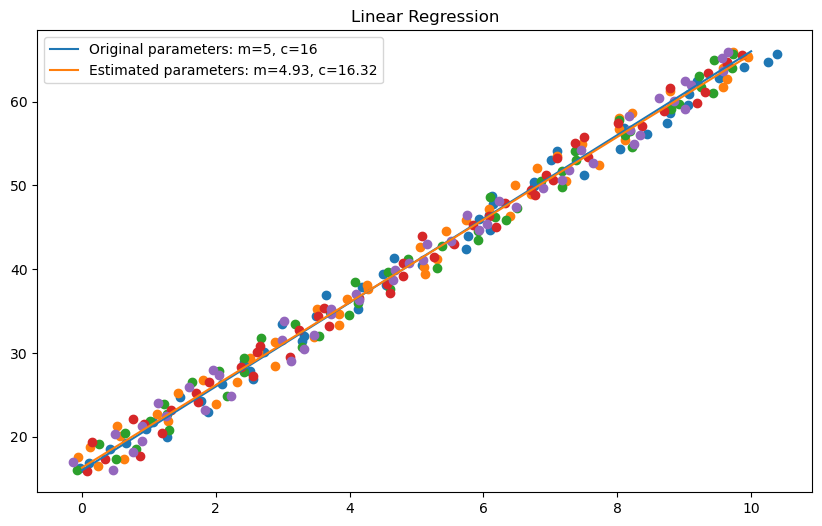

In [5]:
plt.figure(figsize=(10,6))

for _ in range (sim):
    
    plt.scatter(x_samples[_], y_samples[_])
    
plt.plot(true_x, true_y, label=f"Original parameters: m={true_m}, c={true_c}")

bfl_x = np.linspace(0,10,100)
bfl_y = m_mean * bfl_x + c_mean
plt.plot(bfl_x, bfl_y, label=f"Estimated parameters: m={m_mean:.2f}, c={c_mean:.2f}")

plt.title("Linear Regression")
plt.legend()
plt.show()